In [161]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [162]:
# Libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Get data

In [163]:
# Config
years = [2024, 2025]

In [164]:
# Get local race results data for UTMB

# Dictionary | key = year
utmb_race_results_df_dict = dict()
for year in years:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("..", "utmb_under_27h/data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_dict[year] = utmb_year_race_results_df

# Single dataframe with all years
utmb_race_results_df = pd.concat(
    utmb_race_results_df_dict.values(),
    ignore_index=True
).reset_index(drop=True)

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [165]:
# Get sector data for UTMB

# Dictionary | key = year
utmb_sector_data_dict = dict()
for year in years:

    with open(os.path.join(f"data", f"utmb_{year}_sector_data.pkl"), "rb") as f:
        utmb_year_sector_data_dict = pickle.load(f)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_sector_data_dict[year] = utmb_year_sector_data_dict

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


Connect Race data & Sector data - Dict

In [166]:
# Dict((year, bib_number) -> sector data dataframe with race results information

runner_race_sector_data_dict = dict()
for year in years:
    utmb_race_results_year_df = utmb_race_results_df_dict[year]
    utmb_sector_data_year_dict = utmb_sector_data_dict[year]
 
    for bib_number in utmb_sector_data_year_dict.keys():
        utmb_race_results_year_bib_series = utmb_race_results_year_df.query("runner_bib_number == @bib_number").iloc[0]
        
        utmb_sector_data_year_bib_df = (
            utmb_sector_data_year_dict[bib_number]
            .assign(**utmb_race_results_year_bib_series.to_dict())
        )

        runner_race_sector_data_dict[(year, bib_number)] = utmb_sector_data_year_bib_df

In [167]:
# Full dataframe with all years and all runners and their sectors combined
dfs = []
for df in runner_race_sector_data_dict.values():
    if df is None or df.empty:
        continue
    dfs.append(df.dropna(axis=1, how="all"))

runner_race_sector_data_df = pd.concat(dfs, ignore_index=True)

# About data

Work on data

In [168]:
# Runner/Race/Year unique identifier - Runner ID
runner_race_sector_data_df = runner_race_sector_data_df.assign(
    runner_id = lambda x: x.groupby([
        "runner_bib_number",
        "race_id",
        "year",
    ]).ngroup() + 1
)

In [169]:
# Work on some other "new" columns

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        sector_time_min = lambda df: pd.to_timedelta(df["sector_time"]).dt.total_seconds() / 60,
        sector_race_time_at_checkpoint_min = lambda df: pd.to_timedelta(df["sector_race_time_at_checkpoint"]).dt.total_seconds() / 60,
        sector_rest_time_min = lambda df: pd.to_timedelta(df["sector_rest_time"]).dt.total_seconds() / 60,
    )
)

About data

In [170]:
# About data
print("About data:")
print("-------------------------------------")
print("Race IDs: {}".format(runner_race_sector_data_df["race_id"].unique()))
print("Race names: {}".format(runner_race_sector_data_df["race_name"].unique()))
print("Years: {}".format(runner_race_sector_data_df["year"].unique()))
print("Number of unique runners: {:,}".format(runner_race_sector_data_df["runner_url"].nunique()))
print("Number of unique Runner/Race/Year combinations: {:,}".format(runner_race_sector_data_df["runner_id"].nunique()))

About data:
-------------------------------------
Race IDs: ['utmb']
Race names: ['UTMB®']
Years: [2024 2025]
Number of unique runners: 5,058
Number of unique Runner/Race/Year combinations: 5,249


In [171]:
# About Sectors
print("\nAbout sectors:")
print("-------------------------------------")
print("Number of sector checpoints: {:,}".format(runner_race_sector_data_df["sector_checkpoint_id"].nunique()))
print("Sector checkpoint IDs: {}".format(runner_race_sector_data_df["sector_checkpoint_id"].unique().tolist()))

print("Do all races/years have the same number of sectors? {}".format(
    runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique().nunique() == 1
))

sector_sets = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].apply(lambda s: frozenset(s.unique()))
print("Do all races/years have the same sector IDs? {}".format(
    sector_sets.nunique() == 1
))

expected_sector_count = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
runner_sector_counts = runner_race_sector_data_df.groupby(["race_id", "year", "runner_bib_number"])["sector_checkpoint_id"].nunique()
print("Do all runners have all of the sectors? {}".format(
    runner_sector_counts.groupby(["race_id", "year"]).min().eq(expected_sector_count).all()
))


About sectors:
-------------------------------------
Number of sector checpoints: 28
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 23, 24, 27, 30, 31, 33, 34, 35, 44, 144]
Do all races/years have the same number of sectors? False
Do all races/years have the same sector IDs? False
Do all runners have all of the sectors? True


In [172]:
# How are DNF runners represented after their final reached checkpoint? --> They have missing values for all sectors after DNF race time
runner_race_sector_data_dnf_df = runner_race_sector_data_df.loc[~runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()
runner_race_sector_data_finisher_df = runner_race_sector_data_df.loc[runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()

Other data work

In [ ]:
# Sector IDs: 0-max, not "random" values (Race/Year specific)
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        sector_checkpoint_number = lambda x: x
        .groupby(["race_id", "year"])["sector_checkpoint_id"]
        .rank(method="dense", ascending=True)
        .astype(int) - 1
    )
)

# Sanity check
check_df = (
    runner_race_sector_data_df[["race_id", "year", "sector_checkpoint_id", "sector_checkpoint_number"]]
    .drop_duplicates()
)

assert (
    check_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
    == check_df.groupby(["race_id", "year"])["sector_checkpoint_number"].nunique()
).all(), "Sector checkpoint mapping is not 1-to-1 within at least one race/year."

assert (
    check_df.groupby(["race_id", "year"])["sector_checkpoint_number"].min() == 0
).all(), "Sector checkpoint numbering does not start at 0 for at least one race/year."

# Assign to original column name
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(sector_checkpoint_id=lambda x: x["sector_checkpoint_number"])
    .drop(columns=["sector_checkpoint_number"])
)

# Race Time Normalization

Estimate expected runner race time based on UTMB index & Race year: T ~ UTMB_index + Race_year + UTMB_index:Race_year

In [173]:
# Data - one row per runner/year
df_race_time_normalization_estimation = (
    runner_race_sector_data_finisher_df
    .drop_duplicates(subset=["runner_id"])
    [["runner_id", "runner_race_time_hours", "runner_overall_index", "year"]]
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [174]:
# Model - Fit & Predict

# Fit 
model_race_time_norm = smf.ols(
    formula = "runner_race_time_hours ~ runner_overall_index * C(year)",
    data = df_race_time_normalization_estimation,
)
fit_race_time_norm = model_race_time_norm.fit()

# Predict & store predictions
y_pred_race_time_norm = fit_race_time_norm.predict(df_race_time_normalization_estimation)
df_race_time_normalization_estimation["runner_race_time_hours_pred"] = y_pred_race_time_norm

In [175]:
# Calculate race time residuals - Absolute & Relative
df_race_time_normalization_estimation = (
    df_race_time_normalization_estimation
    .assign(
        runner_race_time_hours_residual_abs = lambda df: (
            df["runner_race_time_hours"] - df["runner_race_time_hours_pred"]
        ),
        runner_race_time_hours_residual_prc = lambda df: (
            df["runner_race_time_hours"] / df["runner_race_time_hours_pred"] - 1
        ),
    )
)

In [176]:
# Coefficients
coef_race_time_norm_df = (
    pd.DataFrame({
        "coef": fit_race_time_norm.params,
        "std_err": fit_race_time_norm.bse,
        "p_value": fit_race_time_norm.pvalues,
        "ci_lower": fit_race_time_norm.conf_int()[0],
        "ci_upper": fit_race_time_norm.conf_int()[1],
    })
    .reset_index(names="term")
)

coef_race_time_norm_df

,term,coef,std_err,p_value,ci_lower,ci_upper
0,Intercept,69.630598,0.480596,0.000000,68.688313,70.572884
1,C(year)[T.2025],0.034116,0.677748,0.959856,-1.294717,1.362949
2,runner_overall_index,-0.053391,0.000827,0.000000,-0.055014,-0.051769
3,runner_overall_index:C(year)[T.2025],-0.000431,0.001177,0.714486,-0.002738,0.001877


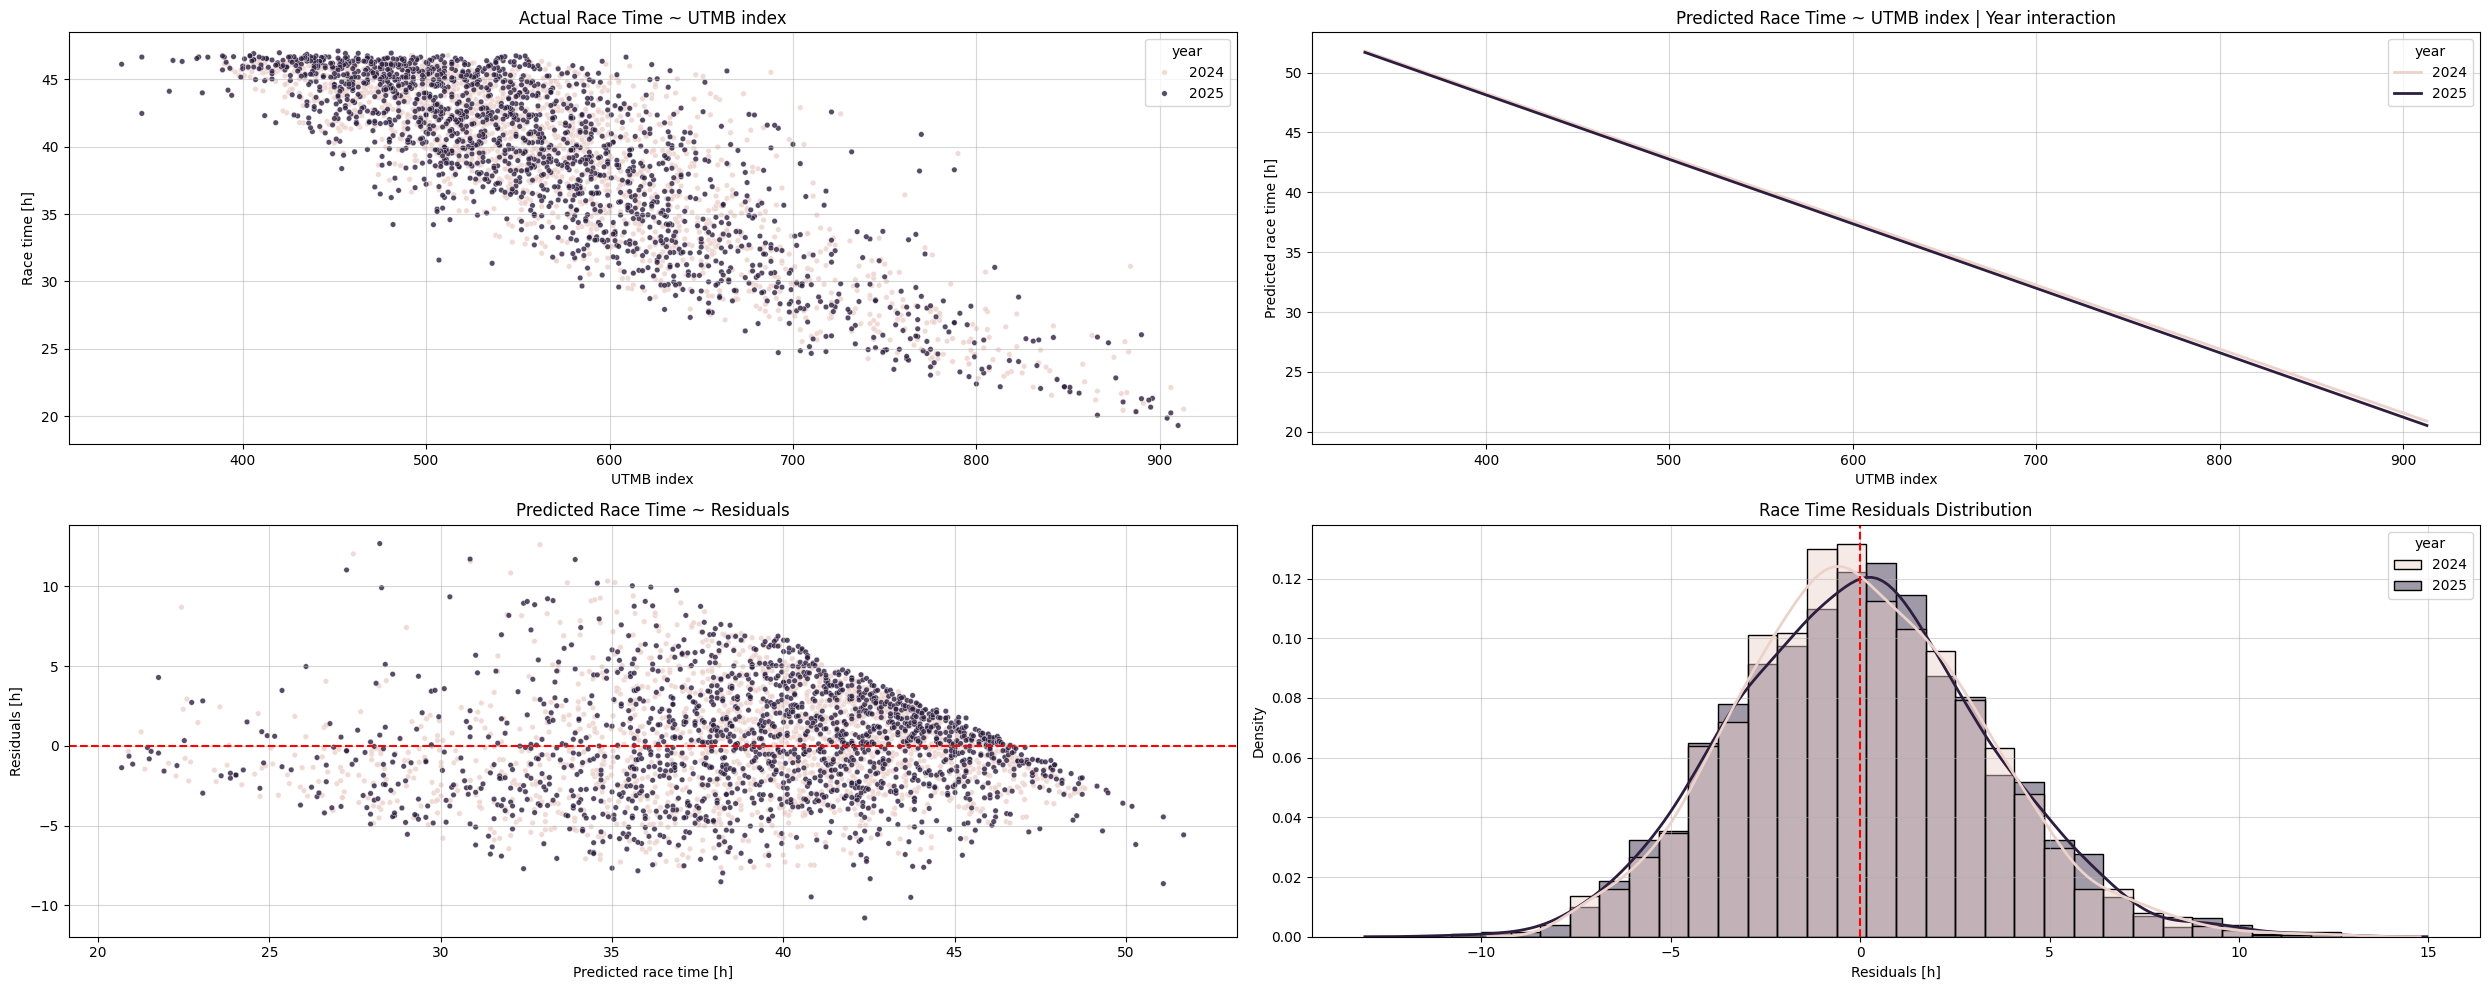

In [177]:
# Model diagnostic

fig, ax = plt.subplots(2, 2, figsize=(25, 10))

# Prediction grid for model lines
utmb_index_grid = np.linspace(
    df_race_time_normalization_estimation["runner_overall_index"].min(),
    df_race_time_normalization_estimation["runner_overall_index"].max(),
    100,
)

pred_grid_df = pd.concat(
    [
        pd.DataFrame({
            "runner_overall_index": utmb_index_grid,
            "year": year,
        })
        for year in sorted(df_race_time_normalization_estimation["year"].unique())
    ],
    ignore_index=True,
)

pred_grid_df = pred_grid_df.assign(
    runner_race_time_hours_pred=fit_race_time_norm.predict(pred_grid_df)
)

# Actual Race Time ~ UTMB index
ax[0, 0].set_title("Actual Race Time ~ UTMB index")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_overall_index",
    y="runner_race_time_hours",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[0, 0],
)
ax[0, 0].set_xlabel("UTMB index")
ax[0, 0].set_ylabel("Race time [h]")

# Model prediction lines by year
ax[0, 1].set_title("Predicted Race Time ~ UTMB index | Year interaction")
sns.lineplot(
    data=pred_grid_df,
    x="runner_overall_index",
    y="runner_race_time_hours_pred",
    hue="year",
    # color="black",
    linewidth=2,
    ax=ax[0, 1],
)
ax[0, 1].set_xlabel("UTMB index")
ax[0, 1].set_ylabel("Predicted race time [h]")

# Predicted values vs. residuals
ax[1, 0].set_title("Predicted Race Time ~ Residuals")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_pred",
    y="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[1, 0],
    legend=False,
)
ax[1, 0].axhline(0, color="red", linestyle="--")
ax[1, 0].set_xlabel("Predicted race time [h]")
ax[1, 0].set_ylabel("Residuals [h]")

# Residuals distribution
ax[1, 1].set_title("Race Time Residuals Distribution")
sns.histplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax[1, 1],
)
sns.kdeplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    common_norm=False,
    linewidth=2,
    ax=ax[1, 1],
    legend=False,
)
ax[1, 1].axvline(0, color="red", linestyle="--")
ax[1, 1].set_xlabel("Residuals [h]")
ax[1, 1].set_ylabel("Density")

for i in [0, 1]:
    for j in [0, 1]:
        ax[i, j].grid(alpha=0.5)

plt.tight_layout()
plt.show()